# **Case Study: Persistent Homology on Temperature Time-Series**

This notebook demonstrates how to construct a **time-delay embedding** of a real-world periodic signal (monthly average temperatures in Central Park, New York City) and prepare it for Topological Data Analysis (TDA).

In [2]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
palette = sns.color_palette("bright")

from core.persistence import rips_filtration, PersistenceDiagram

### **The Dataset**

We use the average monthly temperatures (in °C) recorded in Central Park, NYC for the years 2020 and 2021 (24 data points).

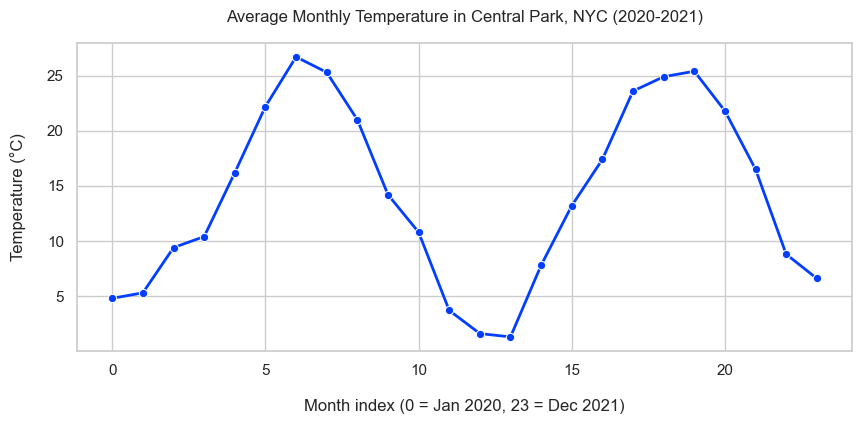

In [3]:
temps = np.array([
    4.8,  5.3,  9.4, 10.4, 16.2, 22.2, 26.7, 25.3, 21.0, 14.2, 10.8,  3.7,  # 2020
    1.6,  1.3,  7.8, 13.2, 17.4, 23.6, 24.9, 25.4, 21.8, 16.5,  8.8,  6.6   # 2021
])

months = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun", 
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
] * 2

plt.figure(figsize=(10, 4))
sns.lineplot(data=temps, marker='o', color=palette[0], linewidth=2)
plt.title("Average Monthly Temperature in Central Park, NYC (2020-2021)", pad=15)
plt.xlabel("Month index (0 = Jan 2020, 23 = Dec 2021)", labelpad=15)
plt.ylabel("Temperature (°C)", labelpad=15)
plt.show()

### **Time-Delay Embedding**

To reconstruct the phase space, we map each value $x_t$ to a 2D coordinate $(x_t, x_{t+\tau})$ with a time delay of $\tau = 3$ months (which corresponds to a 90-degree phase shift in a 12-month period).

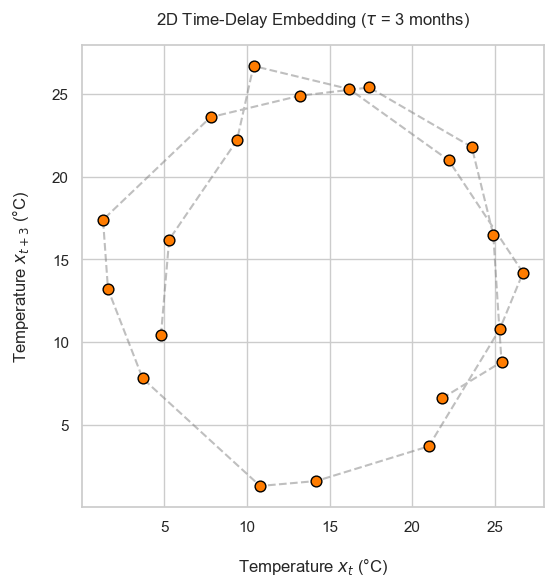

In [4]:
tau = 3
x = temps[:-tau]
y = temps[tau:]
points = np.column_stack([x, y])

plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1], color=palette[1], s=60, edgecolors='black', zorder=3)
plt.plot(points[:, 0], points[:, 1], '--', color='gray', alpha=0.5)
plt.title(f"2D Time-Delay Embedding ($\\tau$ = {tau} months)", pad=15)
plt.xlabel("Temperature $x_t$ (°C)", labelpad=15)
plt.ylabel(f"Temperature $x_{{t+{tau}}}$ (°C)", labelpad=15)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.show()

### **Persistent Homology Analysis**

We proceed by creating a Vietoris-Rips filtration and extracting topological information.

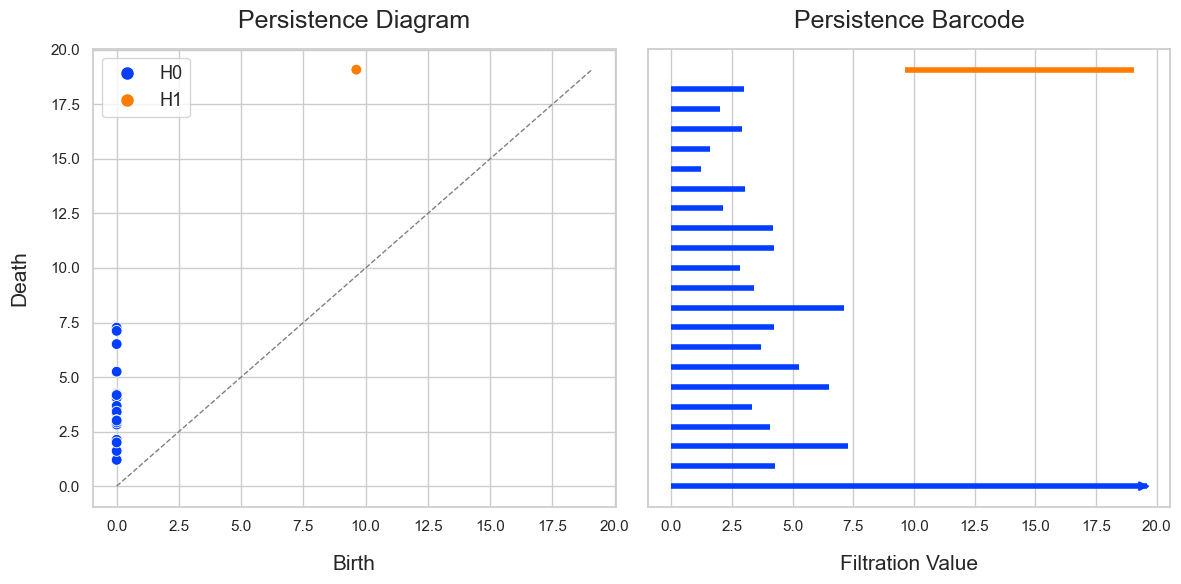

In [5]:
F = rips_filtration(points)
pairs = F.extract_pairs()

clean_pairs = []
for p in pairs:
    if p.birth == p.death:
        continue    
    if p.dim == 2:
        continue
    clean_pairs.append(p)

PD = PersistenceDiagram()
for pair in clean_pairs:
    PD.add_pair(pair)

PD.plot_diagram()

### **Interpretation of Results**

These empirical results align with the theoretical expectations of Takens' delay embedding theorem for periodic systems. We observe a single, prominent generator of the first homology group ($H_1$) birthed at a filtration threshold of $\epsilon \approx 10$, which subsequently becomes a boundary (dies) at $\epsilon \approx 19$.